In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("white")

In [4]:
df = pd.read_csv("german_credit_data_100k.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,35,male,2,own,NaN,NaN,3843,30,radio/TV,good
1,1,51,female,2,own,NaN,little,2911,11,education,good
2,2,49,female,1,rent,little,little,7658,31,radio/TV,bad
3,3,47,male,1,rent,NaN,NaN,1765,17,education,good
4,4,27,male,2,own,little,moderate,3608,40,vacation/others,bad


In [6]:
df['Age'].describe()

count    100000.000000
mean         35.916520
std          10.673303
min          19.000000
25%          28.000000
50%          36.000000
75%          43.000000
max          75.000000
Name: Age, dtype: float64

In [8]:
# Output: Risk = good (low risk)
#         Risk = bad (High risk)

In [9]:
df['Risk'].value_counts()

Risk
good    70109
bad     29891
Name: count, dtype: int64

In [10]:
df.shape

(100000, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Unnamed: 0        100000 non-null  int64 
 1   Age               100000 non-null  int64 
 2   Sex               100000 non-null  object
 3   Job               100000 non-null  int64 
 4   Housing           100000 non-null  object
 5   Saving accounts   81747 non-null   object
 6   Checking account  60659 non-null   object
 7   Credit amount     100000 non-null  int64 
 8   Duration          100000 non-null  int64 
 9   Purpose           100000 non-null  object
 10  Risk              100000 non-null  object
dtypes: int64(5), object(6)
memory usage: 8.4+ MB


In [18]:
df.isna().sum()

Unnamed: 0              0
Age                     0
Sex                     0
Job                     0
Housing                 0
Saving accounts     18253
Checking account    39341
Credit amount           0
Duration                0
Purpose                 0
Risk                    0
dtype: int64

In [19]:
df.duplicated().sum()

0

In [20]:
df = df.dropna().reset_index(drop = True)

In [21]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,2,49,female,1,rent,little,little,7658,31,radio/TV,bad
1,4,27,male,2,own,little,moderate,3608,40,vacation/others,bad
2,8,26,male,2,free,little,little,250,34,radio/TV,bad
3,11,29,female,2,own,little,moderate,5684,42,furniture/equipment,bad
4,12,19,male,2,own,little,moderate,6619,22,furniture/equipment,bad
...,...,...,...,...,...,...,...,...,...,...,...
50479,99988,43,female,1,rent,little,moderate,2293,32,radio/TV,good
50480,99989,43,male,2,own,little,moderate,6582,36,car,bad
50481,99992,47,male,2,own,little,little,9865,66,car,bad
50482,99996,36,female,1,rent,quite rich,moderate,250,5,car,good


In [22]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [23]:
df.drop(columns='Unnamed: 0', inplace = True)

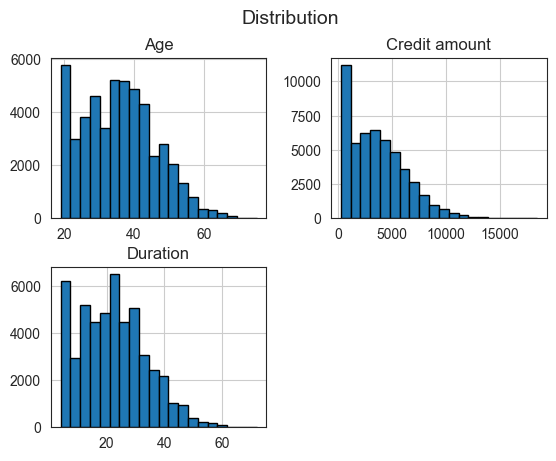

In [24]:
df[['Age','Credit amount','Duration']].hist(bins=20, edgecolor = 'black')
plt.suptitle("Distribution", fontsize = 14)
plt.show()

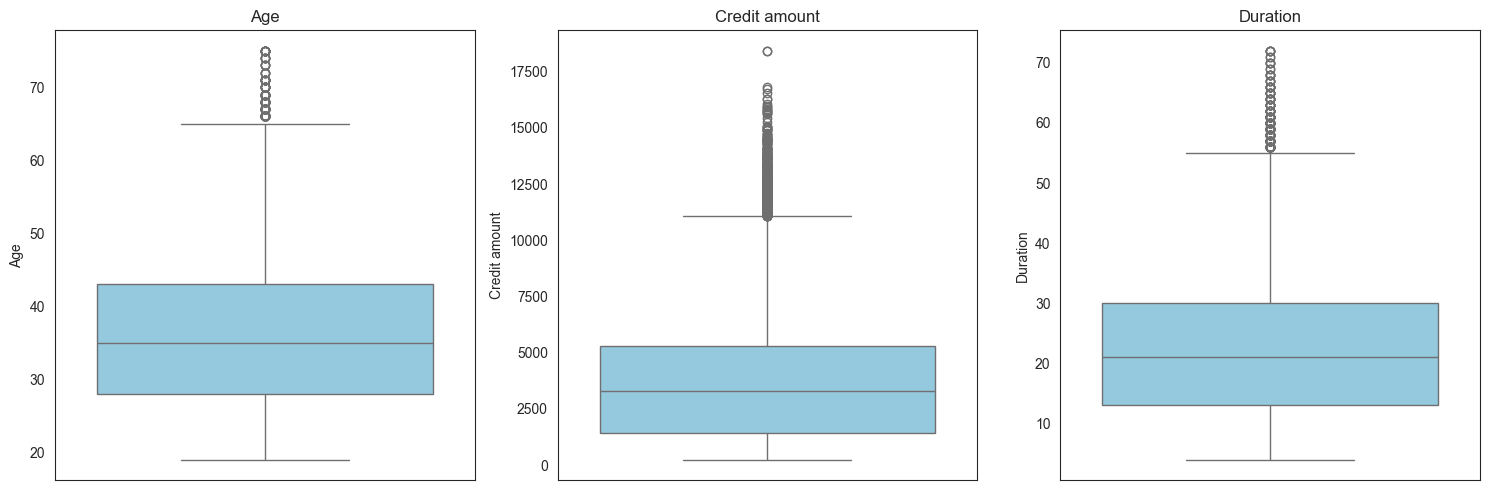

In [25]:
plt.figure(figsize=(15,5))
for i, col in enumerate(['Age','Credit amount', 'Duration']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y = df[col], color ='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [26]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
532,44,female,3,own,little,little,6209,64,car,bad
1071,21,female,2,own,little,little,10837,62,radio/TV,bad
1783,41,female,1,rent,little,little,5820,60,car,bad
2022,25,male,2,rent,little,little,7317,62,car,bad
2077,19,male,1,own,little,little,3403,61,car,bad
...,...,...,...,...,...,...,...,...,...,...
48099,53,male,2,rent,little,little,10225,63,furniture/equipment,bad
48438,40,male,3,own,little,little,12631,61,car,bad
49403,43,male,3,own,little,little,12543,60,furniture/equipment,bad
50020,19,female,2,rent,little,little,5841,62,furniture/equipment,bad


In [27]:
categorical_cols = ['Sex','Job','Housing','Saving accounts', 'Checking account','Purpose' ]

C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_1628\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_1628\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
C:\Users\Ved Dahale\AppData\Local\Temp\ipykernel_1628\4264811852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x =col, palette ='Set2', order 

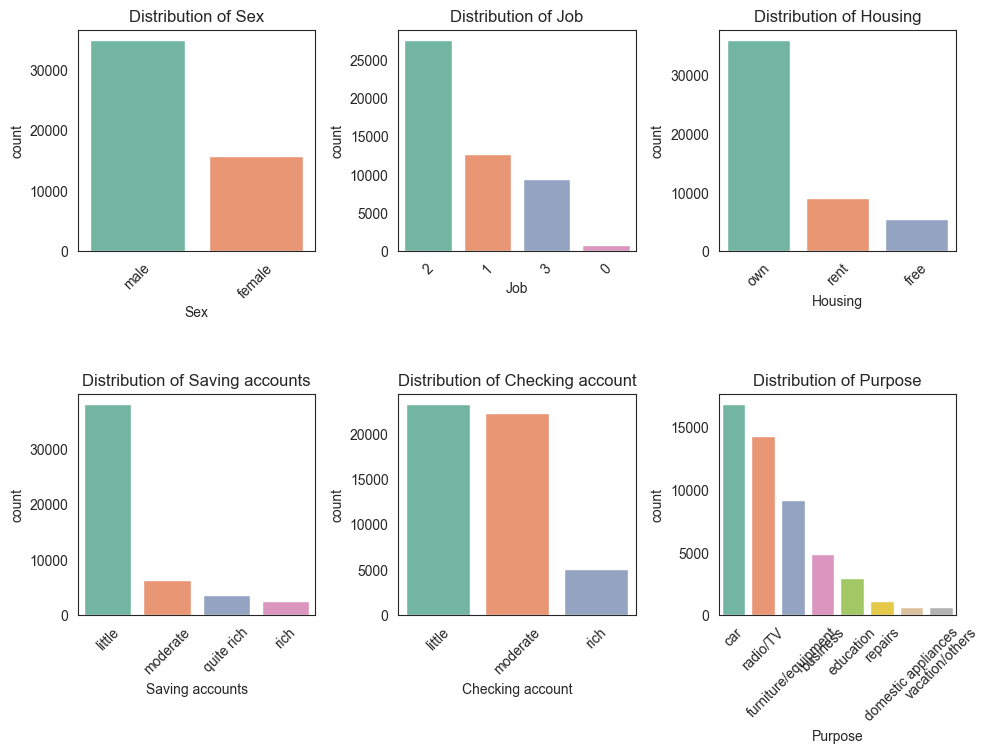

In [30]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data = df, x =col, palette ='Set2', order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
corr = df[['Age','Job', 'Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.050849,0.050494,-0.022503
Job,0.050849,1.000000,0.263024,0.186084
Credit amount,0.050494,0.263024,1.000000,0.600832
Duration,-0.022503,0.186084,0.600832,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

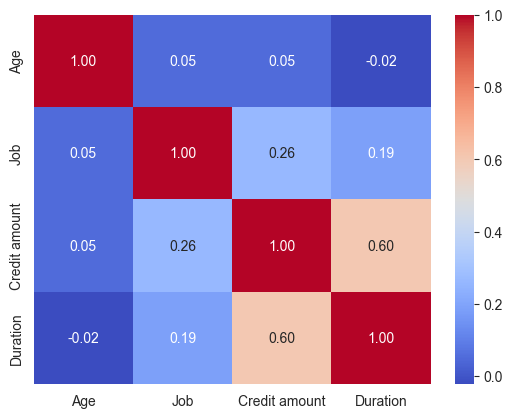

In [35]:
sns.heatmap(corr, annot = True, cmap ='coolwarm', fmt ='.2f')
plt.show

In [36]:
df.groupby('Job')['Credit amount'].mean()


Job
0    1931.669211
1    2747.743620
2    3636.075620
3    4807.236895
Name: Credit amount, dtype: float64